In [1]:
import os

for folder in ["src", "data", "outputs", "docs"]:
    os.makedirs(folder, exist_ok=True)

print("✓ Folders created: src/ | data/ | outputs/ | docs/")

✓ Folders created: src/ | data/ | outputs/ | docs/


In [2]:
!pip install pandas numpy scikit-learn matplotlib langchain langchain-community langchain-core langchain-openai openai python-dotenv -q
print("✓ All dependencies installed")

✓ All dependencies installed


In [ ]:
%%writefile src/agents.py
"""
agents.py
=========
All 5 Agent implementations for the Agentic AI Healthcare System
"""

from __future__ import annotations
import json, os, textwrap
from dataclasses import dataclass, field, asdict
from typing import Any, Dict, List, Optional

try:
    from langchain.schema import HumanMessage, SystemMessage
    from langchain_openai import ChatOpenAI
    _LANGCHAIN_AVAILABLE = True
except ImportError:
    _LANGCHAIN_AVAILABLE = False


# ── Data Structures ───────────────────────────────────────────────────────────

@dataclass
class PatientRecord:
    patient_id: str
    age: int
    sex: str
    bmi: float
    spo2_mean: float
    spo2_min: float
    nasal_airflow_mean: float
    thoracic_effort_mean: float
    ahi: Optional[float] = None
    notes: str = ""

@dataclass
class AgentOutput:
    agent_name: str
    status: str                        # "success" | "warning" | "error"
    data: Dict[str, Any]               = field(default_factory=dict)
    reasoning: str                     = ""
    recommendations: List[str]         = field(default_factory=list)


# ── 1. DATA AGENT ─────────────────────────────────────────────────────────────

class DataAgent:
    REQUIRED_FIELDS = [
        "patient_id", "age", "sex", "bmi",
        "spo2_mean", "spo2_min",
        "nasal_airflow_mean", "thoracic_effort_mean",
    ]
    VALID_RANGES = {
        "age":                   (0,   120),
        "bmi":                   (10,  80),
        "spo2_mean":             (70,  100),
        "spo2_min":              (50,  100),
        "nasal_airflow_mean":    (0,   1),
        "thoracic_effort_mean":  (0,   1),
    }

    def process(self, raw: Dict[str, Any]) -> AgentOutput:
        # 1. Field presence check
        missing = [f for f in self.REQUIRED_FIELDS if f not in raw]
        if missing:
            return AgentOutput(
                agent_name="DataAgent", status="error",
                reasoning=f"Missing required fields: {missing}"
            )

        # 2. Range validation
        warnings = []
        for field_name, (lo, hi) in self.VALID_RANGES.items():
            val = float(raw.get(field_name, 0))
            if not (lo <= val <= hi):
                warnings.append(
                    f"Field '{field_name}' = {val} is outside expected range [{lo}, {hi}]."
                )

        # 3. Feature engineering
        spo2_drop = raw["spo2_mean"] - raw["spo2_min"]
        odi_proxy = spo2_drop / 3.0
        fli       = (1.0 - raw["nasal_airflow_mean"]) * raw["thoracic_effort_mean"]

        record = PatientRecord(
            patient_id            = str(raw["patient_id"]),
            age                   = int(raw["age"]),
            sex                   = str(raw["sex"]).upper(),
            bmi                   = float(raw["bmi"]),
            spo2_mean             = float(raw["spo2_mean"]),
            spo2_min              = float(raw["spo2_min"]),
            nasal_airflow_mean    = float(raw["nasal_airflow_mean"]),
            thoracic_effort_mean  = float(raw["thoracic_effort_mean"]),
            ahi                   = raw.get("ahi"),
            notes                 = str(raw.get("notes", "")),
        )

        return AgentOutput(
            agent_name = "DataAgent",
            status     = "warning" if warnings else "success",
            data = {
                "record": asdict(record),
                "derived": {
                    "spo2_drop_pct":         round(spo2_drop, 2),
                    "odi_proxy_per_hr":      round(odi_proxy, 2),
                    "flow_limitation_index": round(fli, 3),
                },
            },
            reasoning = "\n".join(warnings) if warnings else "All fields validated successfully.",
        )


# ── 2. ANALYSIS AGENT ─────────────────────────────────────────────────────────

class AnalysisAgent:
    AHI_THRESHOLDS = {
        "None":     (0,  5),
        "Mild":     (5,  15),
        "Moderate": (15, 30),
        "Severe":   (30, float("inf")),
    }

    def _estimate_ahi(self, derived, record) -> float:
        odi   = derived["odi_proxy_per_hr"]
        fli   = derived["flow_limitation_index"]
        bmi_f = max(0.0, (record["bmi"] - 25) / 10)
        return round(odi * 3.5 + fli * 20 + bmi_f * 2, 1)

    def _classify_severity(self, ahi: float) -> str:
        for label, (lo, hi) in self.AHI_THRESHOLDS.items():
            if lo <= ahi < hi:
                return label
        return "Unknown"

    def process(self, data_output: AgentOutput) -> AgentOutput:
        if data_output.status == "error":
            return AgentOutput(
                agent_name="AnalysisAgent", status="error",
                reasoning="Upstream DataAgent reported an error."
            )

        record  = data_output.data["record"]
        derived = data_output.data["derived"]

        ahi_known = record.get("ahi") is not None
        ahi       = record["ahi"] if ahi_known else self._estimate_ahi(derived, record)
        severity  = self._classify_severity(ahi)

        hypo_risk = (
            "High"     if record["spo2_min"] < 85 else
            "Moderate" if record["spo2_min"] < 90 else
            "Low"
        )

        fli = derived["flow_limitation_index"]
        apnea_type = (
            "Obstructive (OSA)"    if fli > 0.35 else
            "Central (CSA) proxy"  if fli < 0.15 and derived["odi_proxy_per_hr"] > 5 else
            "Mixed / Undetermined"
        )

        recs = []
        if severity in ("Moderate", "Severe"):
            recs.append("Urgent referral to sleep specialist recommended.")
        if hypo_risk == "High":
            recs.append("Supplemental oxygen assessment warranted.")
        if "Obstructive" in apnea_type and ahi >= 15:
            recs.append("CPAP therapy evaluation advised.")

        return AgentOutput(
            agent_name = "AnalysisAgent",
            status     = "success",
            data = {
                "ahi":             ahi,
                "ahi_source":      "measured" if ahi_known else "estimated",
                "severity":        severity,
                "hypoxaemia_risk": hypo_risk,
                "apnea_type":      apnea_type,
            },
            reasoning = (
                f"AHI: {ahi:.1f} events/hr ({'measured' if ahi_known else 'estimated'})\n"
                f"Severity: {severity} | Hypoxaemia: {hypo_risk} | Apnea: {apnea_type}\n"
                f"FLI: {fli:.3f} | ODI proxy: {derived['odi_proxy_per_hr']:.1f}"
            ),
            recommendations = recs,
        )


# ── 3. KNOWLEDGE RETRIEVAL AGENT ─────────────────────────────────────────────

class KnowledgeRetrievalAgent:
    KNOWLEDGE_BASE = {
        "severity_guidelines": {
            "None":     "No treatment required; lifestyle counselling for high-risk factors.",
            "Mild":     "Conservative management: weight loss, positional therapy, oral appliances.",
            "Moderate": "CPAP therapy first line; oral appliance for CPAP-intolerant patients.",
            "Severe":   "Immediate CPAP/BiPAP initiation; consider surgical evaluation (UPPP/MMA).",
        },
        "comorbidity_risks": {
            "hypertension":   "OSA doubles hypertension risk; CPAP reduces nocturnal BP by 2-3 mmHg.",
            "cardiovascular": "Moderate-severe OSA associated with 2x increased AF risk.",
            "diabetes_t2":    "Untreated OSA worsens insulin resistance; AHI correlates with HbA1c.",
            "stroke":         "Severe OSA (AHI > 30) increases stroke risk by ~3x (SHHS data).",
        },
        "cpap_efficacy": "CPAP reduces AHI by >50% in >80% of patients (Giles et al. 2006).",
        "ahi_definitions": {
            "apnea":    "Complete cessation of airflow >= 10 seconds.",
            "hypopnea": ">=30% reduction in airflow with >=3% SpO2 drop or arousal (AASM 2012).",
            "ahi":      "Number of apnea + hypopnea events per hour of sleep.",
        },
    }

    def process(self, analysis_output: AgentOutput) -> AgentOutput:
        if analysis_output.status == "error":
            return AgentOutput(
                agent_name="KnowledgeRetrievalAgent", status="error",
                reasoning="Cannot retrieve knowledge: upstream error."
            )

        severity = analysis_output.data.get("severity", "Unknown")
        ahi      = analysis_output.data.get("ahi", 0)

        guideline     = self.KNOWLEDGE_BASE["severity_guidelines"].get(severity, "Consult specialist.")
        comorbidities = []
        if ahi >= 15:
            comorbidities.append(self.KNOWLEDGE_BASE["comorbidity_risks"]["hypertension"])
            comorbidities.append(self.KNOWLEDGE_BASE["comorbidity_risks"]["cardiovascular"])
        if ahi >= 30:
            comorbidities.append(self.KNOWLEDGE_BASE["comorbidity_risks"]["stroke"])

        cpap_note = self.KNOWLEDGE_BASE["cpap_efficacy"] if ahi >= 15 else ""

        return AgentOutput(
            agent_name = "KnowledgeRetrievalAgent",
            status     = "success",
            data = {
                "severity_guideline": guideline,
                "comorbidity_risks":  comorbidities,
                "cpap_efficacy_note": cpap_note,
                "ahi_definitions":    self.KNOWLEDGE_BASE["ahi_definitions"],
            },
            reasoning = (
                f"Retrieved guideline for '{severity}' severity. "
                f"Identified {len(comorbidities)} comorbidity risk(s)."
            ),
        )


# ── 4. RECOMMENDATION AGENT ───────────────────────────────────────────────────

class RecommendationAgent:
    def __init__(self):
        self._llm = None
        if _LANGCHAIN_AVAILABLE and os.getenv("OPENAI_API_KEY"):
            try:
                self._llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.2)
            except Exception:
                self._llm = None

    def _heuristic(self, record, analysis, knowledge) -> str:
        sev   = analysis.data.get("severity", "Unknown")
        ahi   = analysis.data.get("ahi", 0)
        hypo  = analysis.data.get("hypoxaemia_risk", "Unknown")
        atype = analysis.data.get("apnea_type", "Unknown")
        guide = knowledge.data.get("severity_guideline", "")
        comor = knowledge.data.get("comorbidity_risks", [])
        cpap  = knowledge.data.get("cpap_efficacy_note", "")

        lines = [
            f"Patient {record['patient_id']} ({record['sex']}, {record['age']} yrs, "
            f"BMI {record['bmi']:.1f}) presents with {sev} Sleep Apnea "
            f"(AHI ~ {ahi:.1f} events/hr, {analysis.data.get('ahi_source','')}).",
            "",
            f"Apnea type: {atype}.",
            f"Nocturnal hypoxaemia risk: {hypo} (min SpO2 = {record['spo2_min']}%).",
            "",
            f"Clinical guideline: {guide}",
        ]
        if cpap:
            lines += ["", f"Evidence note: {cpap}"]
        if comor:
            lines += ["", "Comorbidity risks:"]
            lines += [f"  - {c}" for c in comor]
        return "\n".join(lines)

    def _llm_summary(self, record, analysis, knowledge) -> str:
        context = json.dumps({
            "patient":   record,
            "analysis":  analysis.data,
            "knowledge": knowledge.data,
        }, indent=2)
        try:
            response = self._llm([
                SystemMessage(content=(
                    "You are a clinical AI assistant specialising in sleep medicine. "
                    "Given structured patient data and analysis, produce a concise "
                    "3-5 sentence clinical summary followed by numbered management "
                    "recommendations. Use plain medical English. Do not hallucinate."
                )),
                HumanMessage(content=f"Patient context:\n{context}\n\nGenerate the clinical summary.")
            ])
            return response.content
        except Exception:
            return self._heuristic(record, analysis, knowledge)

    def process(self, data_output, analysis_output, knowledge_output) -> AgentOutput:
        if any(o.status == "error" for o in [data_output, analysis_output, knowledge_output]):
            return AgentOutput(
                agent_name="RecommendationAgent", status="error",
                reasoning="One or more upstream agents reported an error."
            )

        record = data_output.data["record"]
        if self._llm:
            summary = self._llm_summary(record, analysis_output, knowledge_output)
            method  = "LLM-powered (GPT-3.5-turbo via LangChain)"
        else:
            summary = self._heuristic(record, analysis_output, knowledge_output)
            method  = "Heuristic (rule-based; LLM unavailable)"

        # Deduplicate recommendations from all upstream agents
        all_recs    = analysis_output.recommendations + knowledge_output.recommendations
        seen        = set()
        unique_recs = []
        for r in all_recs:
            if r not in seen:
                seen.add(r)
                unique_recs.append(r)

        return AgentOutput(
            agent_name = "RecommendationAgent",
            status     = "success",
            data = {
                "clinical_summary": summary,
                "summary_method":   method,
                "severity":         analysis_output.data.get("severity"),
                "ahi":              analysis_output.data.get("ahi"),
            },
            reasoning        = f"Summary generated using: {method}",
            recommendations  = unique_recs,
        )


# ── 5. ORCHESTRATOR AGENT ─────────────────────────────────────────────────────

class OrchestratorAgent:
    def __init__(self):
        self.data_agent            = DataAgent()
        self.analysis_agent        = AnalysisAgent()
        self.knowledge_agent       = KnowledgeRetrievalAgent()
        self.recommendation_agent  = RecommendationAgent()

    def run(self, raw_patient_data: Dict[str, Any]) -> Dict[str, Any]:
        print(f"\n{'='*60}")
        print(f"  Orchestrator: Processing {raw_patient_data.get('patient_id','?')}")
        print(f"{'='*60}")

        print("[1/4] DataAgent        -> Validating & enriching...")
        data_out = self.data_agent.process(raw_patient_data)
        print(f"      Status: {data_out.status}")

        print("[2/4] AnalysisAgent    -> Classifying severity...")
        analysis_out = self.analysis_agent.process(data_out)
        print(f"      Status: {analysis_out.status} | Severity: {analysis_out.data.get('severity','N/A')}")

        print("[3/4] KnowledgeAgent   -> Fetching guidelines...")
        knowledge_out = self.knowledge_agent.process(analysis_out)
        print(f"      Status: {knowledge_out.status}")

        print("[4/4] RecommendationAgent -> Synthesising report...")
        rec_out = self.recommendation_agent.process(data_out, analysis_out, knowledge_out)
        print(f"      Status: {rec_out.status}")

        report = {
            "patient_id":            raw_patient_data.get("patient_id"),
            "pipeline_status":       rec_out.status,
            "agents": {
                "DataAgent":               asdict(data_out),
                "AnalysisAgent":           asdict(analysis_out),
                "KnowledgeRetrievalAgent": asdict(knowledge_out),
                "RecommendationAgent":     asdict(rec_out),
            },
            "summary":               rec_out.data.get("clinical_summary", ""),
            "severity":              rec_out.data.get("severity"),
            "estimated_ahi":         rec_out.data.get("ahi"),
            "final_recommendations": rec_out.recommendations,
        }
        print(f"\n  Pipeline complete.")
        return report

Writing src/agents.py


In [4]:
%%writefile src/dataset.py
"""
dataset.py
==========
Synthetic PSG dataset generator for Sleep Apnea screening.
"""

from __future__ import annotations
import random
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)
random.seed(SEED)


def _patient_cohort(n: int, severity: str) -> pd.DataFrame:
    configs = {
        #           ahi_lo  hi   spo2m_mu sd  spo2n_mu sd   fl_mu  sd    ef_mu  sd    bmi_mu sd
        "None":     (0,  5,  97.0, 0.5, 95.0, 1.0, 0.88, 0.06, 0.20, 0.05, 24.0, 3.0),
        "Mild":     (5,  15, 95.5, 0.8, 91.0, 2.0, 0.72, 0.08, 0.40, 0.08, 28.5, 3.5),
        "Moderate": (15, 30, 94.0, 1.0, 87.0, 3.0, 0.55, 0.10, 0.60, 0.09, 32.0, 4.0),
        "Severe":   (30, 80, 91.5, 1.5, 81.0, 4.0, 0.38, 0.12, 0.78, 0.10, 36.5, 5.0),
    }
    (ahi_lo, ahi_hi, spo2m_mu, spo2m_sd, spo2n_mu, spo2n_sd,
     fl_mu, fl_sd, ef_mu, ef_sd, bmi_mu, bmi_sd) = configs[severity]

    n_pts = n
    ages  = np.random.randint(30, 75, n_pts)
    sexes = np.random.choice(["M", "F"], n_pts, p=[0.60, 0.40])
    bmis  = np.clip(np.random.normal(bmi_mu, bmi_sd, n_pts), 16, 55)
    ahis  = np.random.uniform(ahi_lo, ahi_hi, n_pts).round(1)
    spo2m = np.clip(np.random.normal(spo2m_mu, spo2m_sd, n_pts), 85, 99).round(1)
    spo2n = np.clip(np.random.normal(spo2n_mu, spo2n_sd, n_pts), 60, 98).round(1)
    flows = np.clip(np.random.normal(fl_mu, fl_sd, n_pts), 0.05, 1.0).round(3)
    effs  = np.clip(np.random.normal(ef_mu, ef_sd, n_pts), 0.05, 1.0).round(3)
    ids   = [f"PT{severity[0]}{str(i+1).zfill(3)}" for i in range(n_pts)]

    return pd.DataFrame({
        "patient_id":           ids,
        "age":                  ages,
        "sex":                  sexes,
        "bmi":                  bmis.round(1),
        "spo2_mean":            spo2m,
        "spo2_min":             spo2n,
        "nasal_airflow_mean":   flows,
        "thoracic_effort_mean": effs,
        "ahi":                  ahis,
        "severity_label":       severity,
    })


def generate_dataset(
    n_none=30, n_mild=30, n_moderate=25, n_severe=15,
    save_path="data/sleep_apnea_dataset.csv"
) -> pd.DataFrame:
    df = pd.concat([
        _patient_cohort(n_none,     "None"),
        _patient_cohort(n_mild,     "Mild"),
        _patient_cohort(n_moderate, "Moderate"),
        _patient_cohort(n_severe,   "Severe"),
    ], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(save_path, index=False)
    print(f"[Dataset] Saved {len(df)} records -> {save_path}")
    return df

Writing src/dataset.py


In [5]:
%%writefile src/evaluation.py
"""
evaluation.py
=============
Evaluates system performance against ground-truth severity labels.
"""

from __future__ import annotations
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))

from agents import OrchestratorAgent
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


def evaluate(csv_path="data/sleep_apnea_dataset.csv", max_samples=50) -> dict:
    df           = pd.read_csv(csv_path).head(max_samples)
    orchestrator = OrchestratorAgent()
    y_true, y_pred = [], []
    failed = 0

    print(f"\nEvaluating on {len(df)} patients (ground-truth AHI hidden)...")

    for _, row in df.iterrows():
        raw        = row.to_dict()
        true_label = raw.pop("severity_label")
        raw.pop("ahi", None)              # hide ground truth

        try:
            report     = orchestrator.run(raw)
            pred_label = report.get("severity", "Unknown")
        except Exception:
            pred_label = "Unknown"
            failed    += 1

        y_true.append(true_label)
        y_pred.append(pred_label)

    labels = ["None", "Mild", "Moderate", "Severe"]
    acc    = accuracy_score(y_true, y_pred)

    print("\n" + "="*60)
    print("  EVALUATION RESULTS")
    print("="*60)
    print(f"  Samples   : {len(df)}")
    print(f"  Failed    : {failed}")
    print(f"  Accuracy  : {acc*100:.1f}%")
    print("\nPer-class report:")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))
    print("Confusion Matrix (rows=True, cols=Predicted):")
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    print(pd.DataFrame(cm, index=labels, columns=labels).to_string())
    print("="*60)

    return {"accuracy": round(acc, 4), "samples": len(df), "failed": failed}

Writing src/evaluation.py


In [6]:
import sys
sys.path.insert(0, "src")

from agents import (
    DataAgent, AnalysisAgent, KnowledgeRetrievalAgent,
    RecommendationAgent, OrchestratorAgent,
    PatientRecord, AgentOutput
)
print("✓ All 5 agents imported successfully")

✓ All 5 agents imported successfully


In [7]:
from dataset import generate_dataset

df = generate_dataset(save_path="data/sleep_apnea_dataset.csv")

print(f"\nDataset Summary:")
print(f"  Total patients     : {len(df)}")
print(f"  Class distribution : {df['severity_label'].value_counts().to_dict()}")
df.head(5)

[Dataset] Saved 100 records -> data/sleep_apnea_dataset.csv

Dataset Summary:
  Total patients     : 100
  Class distribution : {'Mild': 30, 'None': 30, 'Moderate': 25, 'Severe': 15}


,patient_id,age,sex,bmi,spo2_mean,spo2_min,nasal_airflow_mean,thoracic_effort_mean,ahi,severity_label
0,PTM024,31,F,31.1,93.3,88.8,0.515,0.516,15.1,Moderate
1,PTM024,34,F,30.8,95.0,91.8,0.867,0.478,13.1,Mild
2,PTM011,46,M,32.1,96.6,89.1,0.316,0.368,23.8,Moderate
3,PTM016,35,M,28.5,94.5,89.0,0.732,0.340,12.0,Mild
4,PTM015,71,M,32.6,94.7,91.0,0.659,0.427,6.2,Mild


In [8]:
DEMO_PATIENTS = [
    {
        "patient_id": "DEMO_001", "age": 45, "sex": "M", "bmi": 22.4,
        "spo2_mean": 97.2, "spo2_min": 95.8,
        "nasal_airflow_mean": 0.91, "thoracic_effort_mean": 0.18,
        "notes": "Healthy adult, no reported symptoms",
    },
    {
        "patient_id": "DEMO_002", "age": 52, "sex": "M", "bmi": 29.1,
        "spo2_mean": 95.8, "spo2_min": 91.5,
        "nasal_airflow_mean": 0.73, "thoracic_effort_mean": 0.42,
        "notes": "Occasional snoring, mild daytime sleepiness",
    },
    {
        "patient_id": "DEMO_003", "age": 58, "sex": "F", "bmi": 33.7,
        "spo2_mean": 93.5, "spo2_min": 87.2,
        "nasal_airflow_mean": 0.54, "thoracic_effort_mean": 0.63,
        "notes": "Loud snoring, witnessed apneas, hypertension",
    },
    {
        "patient_id": "DEMO_004", "age": 61, "sex": "M", "bmi": 38.9,
        "spo2_mean": 90.1, "spo2_min": 78.5,
        "nasal_airflow_mean": 0.32, "thoracic_effort_mean": 0.81,
        "notes": "Severe obesity, type-2 diabetes, extreme sleepiness",
    },
    {
        "patient_id": "DEMO_005", "age": 48, "sex": "F", "bmi": 26.8,
        "spo2_mean": 94.2, "spo2_min": 88.1,
        "nasal_airflow_mean": 0.62, "thoracic_effort_mean": 0.22,
        "notes": "Low FLI, possible central component",
    },
]
print(f"✓ {len(DEMO_PATIENTS)} demo patients defined")

✓ 5 demo patients defined


In [9]:
import json

orchestrator = OrchestratorAgent()
all_reports  = []

for patient in DEMO_PATIENTS:
    report = orchestrator.run(patient)
    all_reports.append(report)

print(f"\n✓ Pipeline complete for all {len(all_reports)} demo patients")


  Orchestrator: Processing DEMO_001
[1/4] DataAgent        -> Validating & enriching...
      Status: success
[2/4] AnalysisAgent    -> Classifying severity...
      Status: success | Severity: None
[3/4] KnowledgeAgent   -> Fetching guidelines...
      Status: success
[4/4] RecommendationAgent -> Synthesising report...
      Status: success

  Pipeline complete.

  Orchestrator: Processing DEMO_002
[1/4] DataAgent        -> Validating & enriching...
      Status: success
[2/4] AnalysisAgent    -> Classifying severity...
      Status: success | Severity: Mild
[3/4] KnowledgeAgent   -> Fetching guidelines...
      Status: success
[4/4] RecommendationAgent -> Synthesising report...
      Status: success

  Pipeline complete.

  Orchestrator: Processing DEMO_003
[1/4] DataAgent        -> Validating & enriching...
      Status: success
[2/4] AnalysisAgent    -> Classifying severity...
      Status: success | Severity: Mild
[3/4] KnowledgeAgent   -> Fetching guidelines...
      Status: suc

In [10]:
def print_report(report):
    print("\n" + "-"*60)
    print(f"  PATIENT: {report['patient_id']}")
    print("-"*60)
    print(f"  Status        : {report['pipeline_status']}")
    print(f"  Severity      : {report.get('severity', 'N/A')}")
    ahi = report.get('estimated_ahi')
    print(f"  Estimated AHI : {ahi:.1f} events/hr" if ahi else "  Estimated AHI : N/A")
    print(f"\n  Clinical Summary:")
    for line in report.get("summary", "").splitlines():
        print(f"    {line}")
    recs = report.get("final_recommendations", [])
    if recs:
        print(f"\n  Recommendations ({len(recs)}):")
        for i, r in enumerate(recs, 1):
            print(f"    {i}. {r}")
    print("-"*60)

for report in all_reports:
    print_report(report)


------------------------------------------------------------
  PATIENT: DEMO_001
------------------------------------------------------------
  Status        : success
  Severity      : None
  Estimated AHI : 2.0 events/hr

  Clinical Summary:
    Patient DEMO_001 (M, 45 yrs, BMI 22.4) presents with None Sleep Apnea (AHI ~ 2.0 events/hr, estimated).
    
    Apnea type: Mixed / Undetermined.
    Nocturnal hypoxaemia risk: Low (min SpO2 = 95.8%).
    
    Clinical guideline: No treatment required; lifestyle counselling for high-risk factors.
------------------------------------------------------------

------------------------------------------------------------
  PATIENT: DEMO_002
------------------------------------------------------------
  Status        : success
  Severity      : Mild
  Estimated AHI : 8.1 events/hr

  Clinical Summary:
    Patient DEMO_002 (M, 52 yrs, BMI 29.1) presents with Mild Sleep Apnea (AHI ~ 8.1 events/hr, estimated).
    
    Apnea type: Mixed / Undetermi

In [11]:
with open("outputs/demo_reports.json", "w") as f:
    json.dump(all_reports, f, indent=2, default=str)

print("✓ Saved -> outputs/demo_reports.json")

✓ Saved -> outputs/demo_reports.json


In [12]:
from evaluation import evaluate

metrics = evaluate(
    csv_path   = "data/sleep_apnea_dataset.csv",
    max_samples = 50
)


Evaluating on 50 patients (ground-truth AHI hidden)...

  Orchestrator: Processing PTM024
[1/4] DataAgent        -> Validating & enriching...
      Status: success
[2/4] AnalysisAgent    -> Classifying severity...
      Status: success | Severity: Mild
[3/4] KnowledgeAgent   -> Fetching guidelines...
      Status: success
[4/4] RecommendationAgent -> Synthesising report...
      Status: success

  Pipeline complete.

  Orchestrator: Processing PTM024
[1/4] DataAgent        -> Validating & enriching...
      Status: success
[2/4] AnalysisAgent    -> Classifying severity...
      Status: success | Severity: Mild
[3/4] KnowledgeAgent   -> Fetching guidelines...
      Status: success
[4/4] RecommendationAgent -> Synthesising report...
      Status: success

  Pipeline complete.

  Orchestrator: Processing PTM011
[1/4] DataAgent        -> Validating & enriching...
      Status: success
[2/4] AnalysisAgent    -> Classifying severity...
      Status: success | Severity: Moderate
[3/4] Knowle

In [13]:
with open("outputs/evaluation_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("✓ Saved -> outputs/evaluation_metrics.json")
print(f"\n  Accuracy       : {metrics['accuracy']*100:.1f}%")
print(f"  Samples tested : {metrics['samples']}")
print(f"  Failed runs    : {metrics['failed']}")

✓ Saved -> outputs/evaluation_metrics.json

  Accuracy       : 40.0%
  Samples tested : 50
  Failed runs    : 0


C:\Users\adith\AppData\Local\Temp\ipykernel_15260\1699933239.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_sev, labels=SEV_ORDER, patch_artist=True)


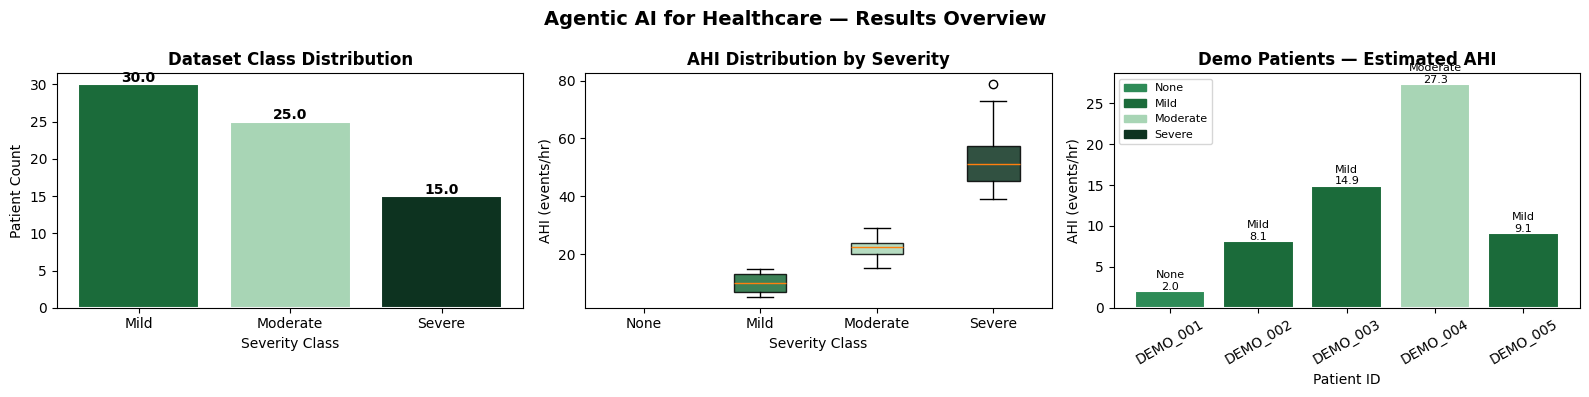

✓ Saved -> outputs/results_overview.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

df = pd.read_csv("data/sleep_apnea_dataset.csv")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Agentic AI for Healthcare — Results Overview",
             fontsize=14, fontweight="bold")

SEV_ORDER  = ["None", "Mild", "Moderate", "Severe"]
SEV_COLORS = ["#2E8B57", "#1B6B3A", "#A8D5B5", "#0d3320"]

# ── Plot 1: Class distribution ────────────────────────────────────────────────
counts = df["severity_label"].value_counts().reindex(SEV_ORDER)
axes[0].bar(counts.index, counts.values, color=SEV_COLORS, edgecolor="white", linewidth=1.5)
axes[0].set_title("Dataset Class Distribution", fontweight="bold")
axes[0].set_ylabel("Patient Count")
axes[0].set_xlabel("Severity Class")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

# ── Plot 2: AHI distribution by severity ─────────────────────────────────────
data_by_sev = [df[df["severity_label"] == s]["ahi"].values for s in SEV_ORDER]
bp = axes[1].boxplot(data_by_sev, labels=SEV_ORDER, patch_artist=True)
for patch, color in zip(bp["boxes"], SEV_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
axes[1].set_title("AHI Distribution by Severity", fontweight="bold")
axes[1].set_ylabel("AHI (events/hr)")
axes[1].set_xlabel("Severity Class")

# ── Plot 3: Demo patient AHI ──────────────────────────────────────────────────
demo_ids   = [r["patient_id"]   for r in all_reports]
demo_ahis  = [r["estimated_ahi"] for r in all_reports]
demo_sevs  = [r["severity"]      for r in all_reports]
sev_color_map = dict(zip(SEV_ORDER, SEV_COLORS))
bar_colors = [sev_color_map.get(s, "gray") for s in demo_sevs]

axes[2].bar(demo_ids, demo_ahis, color=bar_colors, edgecolor="white", linewidth=1.5)
axes[2].set_title("Demo Patients — Estimated AHI", fontweight="bold")
axes[2].set_ylabel("AHI (events/hr)")
axes[2].set_xlabel("Patient ID")
axes[2].tick_params(axis="x", rotation=30)
for i, (v, sev) in enumerate(zip(demo_ahis, demo_sevs)):
    axes[2].text(i, v + 0.2, f"{sev}\n{v:.1f}", ha="center", fontsize=8)

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in zip(SEV_ORDER, SEV_COLORS)]
axes[2].legend(handles=legend_patches, loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("outputs/results_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved -> outputs/results_overview.png")